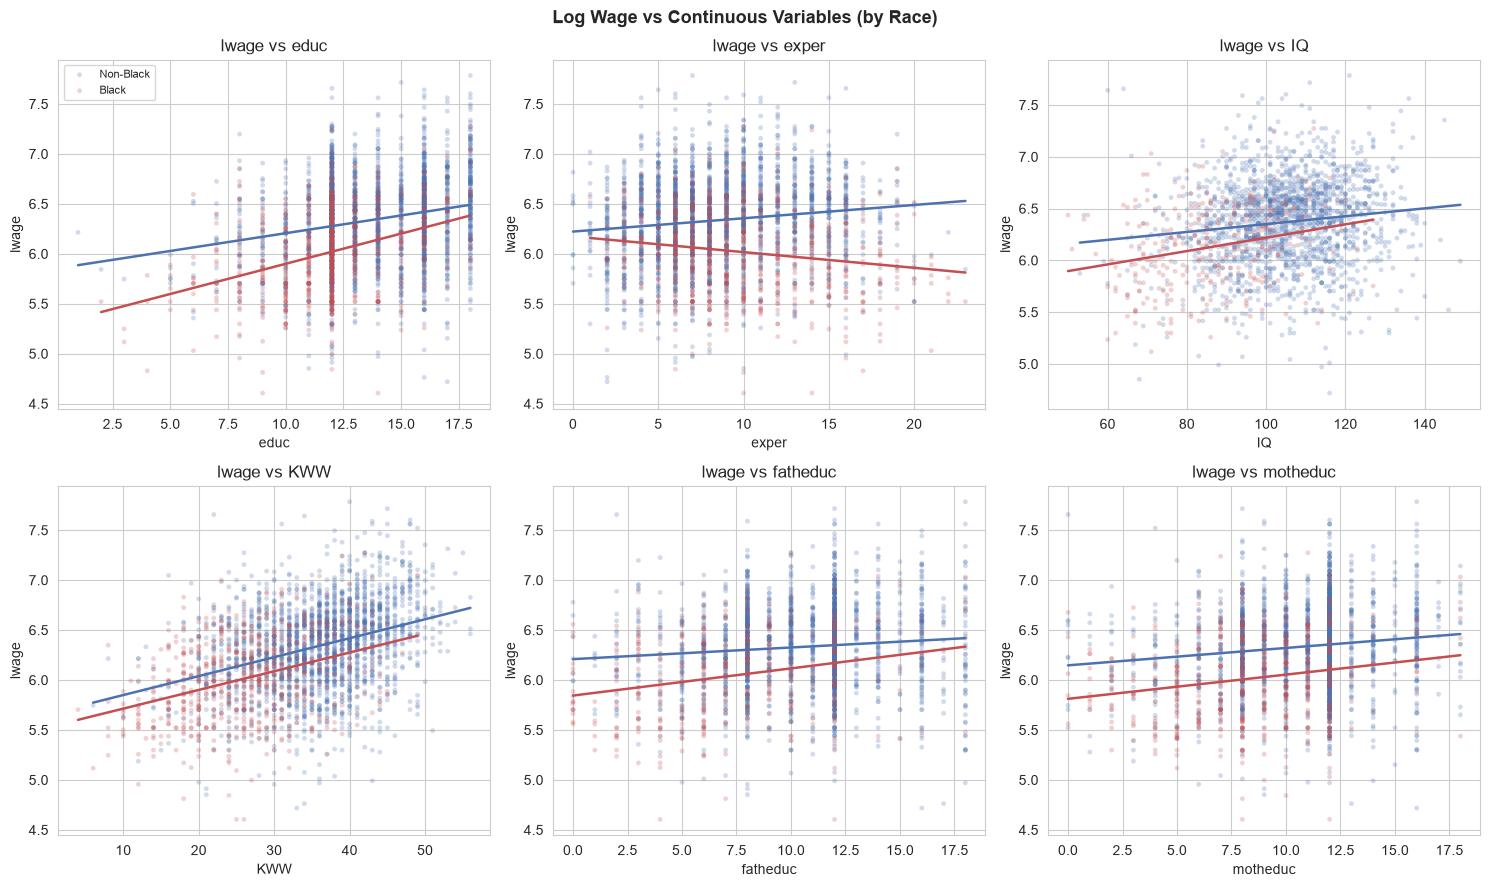

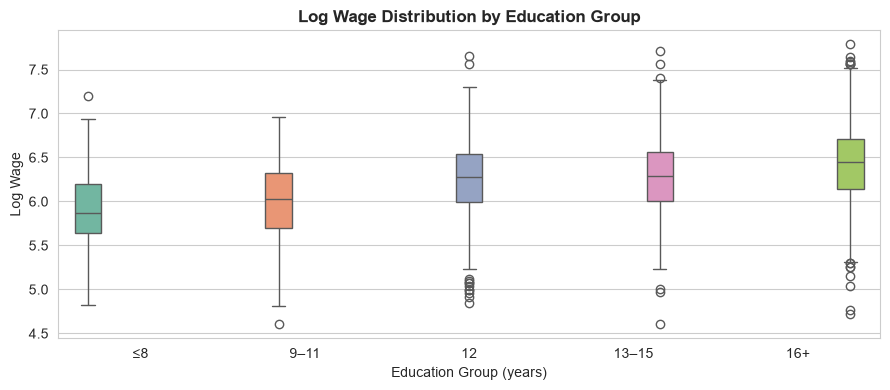

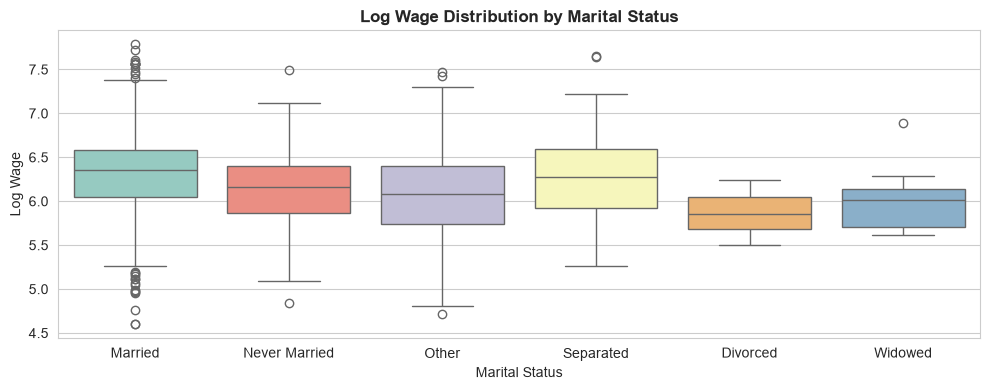

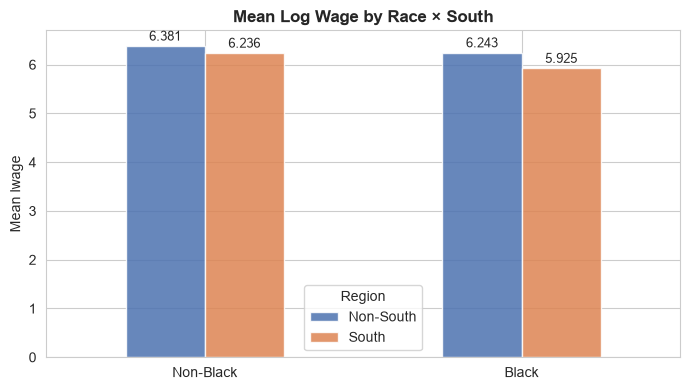

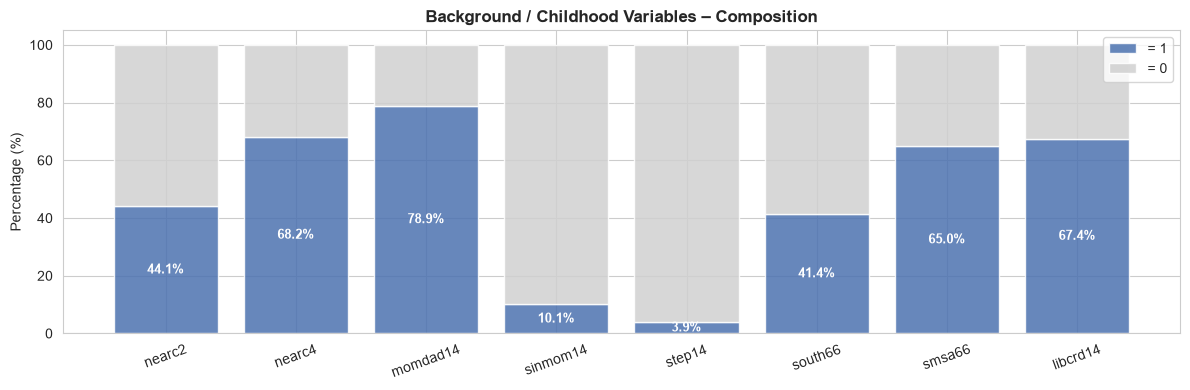

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
df = pd.read_csv("DATA/wage_eda.csv")

# ── 1. Scatter lwage vs continuous vars, colored by race ──────
cont_vars = ["educ", "exper", "IQ", "KWW", "fatheduc", "motheduc"]
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
for i, col in enumerate(cont_vars):
    data = df[["lwage", col, "black"]].dropna()
    for race, color, lbl in [(0,"#4C72B0","Non-Black"), (1,"#C44E52","Black")]:
        sub = data[data["black"] == race]
        axes[i].scatter(sub[col], sub["lwage"], alpha=0.25, s=12,
                        color=color, label=lbl, edgecolors="none")
        m, b = np.polyfit(sub[col], sub["lwage"], 1)
        x_r = np.linspace(sub[col].min(), sub[col].max(), 100)
        axes[i].plot(x_r, m*x_r + b, color=color, linewidth=1.8)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("lwage")
    axes[i].set_title(f"lwage vs {col}")
    if i == 0:
        axes[i].legend(fontsize=8)
fig.suptitle("Log Wage vs Continuous Variables (by Race)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ── 2. Boxplot – lwage by education group ────────────────────
df["educ_grp"] = pd.cut(df["educ"], bins=[0,8,11,12,15,21],
                         labels=["≤8","9–11","12","13–15","16+"])

fig, ax = plt.subplots(figsize=(9, 4))
sns.boxplot(data=df.dropna(subset=["educ_grp"]),
            x="educ_grp", y="lwage",
            hue="educ_grp", palette="Set2",
            order=["≤8","9–11","12","13–15","16+"],
            legend=False, ax=ax)
ax.set_xlabel("Education Group (years)")
ax.set_ylabel("Log Wage")
ax.set_title("Log Wage Distribution by Education Group", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# ── 3. Boxplot – lwage by marital status ─────────────────────
married_map = {1:"Married", 2:"Widowed", 3:"Divorced",
               4:"Separated", 5:"Never Married", 6:"Other"}
df["marital"] = df["married"].map(married_map)

order = ["Married","Never Married","Other","Separated","Divorced","Widowed"]
fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(data=df.dropna(subset=["marital"]),
            x="marital", y="lwage",
            hue="marital", palette="Set3",
            order=order, legend=False, ax=ax)
ax.set_xlabel("Marital Status")
ax.set_ylabel("Log Wage")
ax.set_title("Log Wage Distribution by Marital Status", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# ── 4. Grouped bar – mean lwage by Race × South ──────────────
summary = df.groupby(["black", "south"])["lwage"].mean().unstack()
summary.index = ["Non-Black", "Black"]
summary.columns = ["Non-South", "South"]
ax = summary.plot(kind="bar", figsize=(7, 4),
                  color=["#4C72B0","#DD8452"], edgecolor="white", alpha=0.85)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=2, fontsize=9)
ax.set_title("Mean Log Wage by Race × South", fontsize=12, fontweight="bold")
ax.set_ylabel("Mean lwage")
ax.set_xlabel("")
ax.set_xticklabels(["Non-Black", "Black"], rotation=0)
ax.legend(title="Region")
plt.tight_layout()
plt.show()

# ── 5. Stacked bar – background variables (nearc, momdad, etc.) ─
bg_vars = ["nearc2","nearc4","momdad14","sinmom14","step14","south66","smsa66","libcrd14"]
pct1 = df[bg_vars].mean() * 100
pct0 = 100 - pct1

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(bg_vars, pct1, label="= 1", color="#4C72B0", alpha=0.85)
ax.bar(bg_vars, pct0, bottom=pct1, label="= 0", color="#D0D0D0", alpha=0.85)
for i, (col, v) in enumerate(pct1.items()):
    ax.text(i, v/2, f"{v:.1f}%", ha="center", va="center", fontsize=9, color="white", fontweight="bold")
ax.set_ylabel("Percentage (%)")
ax.set_title("Background / Childhood Variables – Composition", fontsize=12, fontweight="bold")
ax.tick_params(axis="x", rotation=20)
ax.legend()
plt.tight_layout()
plt.show()